In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
(x_train,_),(_,_)=mnist.load_data()
x_train=x_train/255.0

In [3]:
class Sampling(keras.layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        epsilon = K.random_normal(shape=tf.shape(log_var))
        return mean + K.exp(log_var / 2) * epsilon

In [4]:
class KLDivergenceLayer(keras.layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs

        kl_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.exp(log_var) - tf.square(mean),
            axis=-1
        )

        self.add_loss(tf.reduce_mean(kl_loss))

        return inputs

In [5]:
codings_size = 10

inputs = keras.layers.Input(shape=[28,28])

z = keras.layers.Flatten()(inputs)
z = keras.layers.Dense(128, activation="selu")(z)
z = keras.layers.Dense(64, activation="selu")(z)
z = keras.layers.Dense(32, activation="selu")(z)

codings_mean = keras.layers.Dense(codings_size)(z)
codings_log_var = keras.layers.Dense(codings_size)(z)

codings_mean, codings_log_var = KLDivergenceLayer()(
    [codings_mean, codings_log_var]
)

codings = Sampling()([codings_mean, codings_log_var])

variational_encoder = keras.Model(
    inputs,
    [codings_mean, codings_log_var, codings]
)


In [6]:
decoder_inputs = keras.layers.Input(shape=[codings_size])

x = keras.layers.Dense(128, activation="selu")(decoder_inputs)
x = keras.layers.Dense(64, activation="selu")(x)
x = keras.layers.Dense(32, activation="selu")(x)
x = keras.layers.Dense(28*28, activation="sigmoid")(x)

outputs = keras.layers.Reshape([28,28])(x)

variational_decoder = keras.Model(decoder_inputs, outputs)

In [7]:
_, _, codings = variational_encoder(inputs)
reconstruction = variational_decoder(codings)

variational_ae = keras.Model(inputs, reconstruction)

variational_ae.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop"
)

In [8]:
history = variational_ae.fit(
    x_train,
    x_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4582 - val_loss: 0.3217
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2832 - val_loss: 0.2826
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2735 - val_loss: 0.2678
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2703 - val_loss: 0.2723
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2685 - val_loss: 0.2691
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2672 - val_loss: 0.2652
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2664 - val_loss: 0.2664
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2660 - val_loss: 0.2658
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2657 - val_loss: 0.2640
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2654 - val_loss: 0.2648


In [9]:
codings=tf.random.normal(shape=[12,codings_size])
images=variational_decoder(codings).numpy()
images

array([[[0.00016052, 0.0001683 , 0.00018332, ..., 0.00016913,
         0.00018329, 0.00018324],
        [0.00018104, 0.00017412, 0.00019133, ..., 0.00019422,
         0.00016964, 0.00018887],
        [0.00019221, 0.00017114, 0.00019615, ..., 0.00021347,
         0.00019889, 0.00017823],
        ...,
        [0.00017088, 0.00018618, 0.00017612, ..., 0.0001689 ,
         0.00018821, 0.00017189],
        [0.00018641, 0.00018874, 0.0001985 , ..., 0.00016868,
         0.00016611, 0.00018252],
        [0.0002027 , 0.0002005 , 0.00019964, ..., 0.0001971 ,
         0.00018008, 0.00018579]],

       [[0.00015962, 0.00016792, 0.00018077, ..., 0.00016807,
         0.00018344, 0.00018218],
        [0.00018354, 0.00017292, 0.00019196, ..., 0.00019302,
         0.00016877, 0.0001881 ],
        [0.00018957, 0.0001726 , 0.00019648, ..., 0.00021322,
         0.00019476, 0.00017997],
        ...,
        [0.00016888, 0.00018401, 0.00017565, ..., 0.00016826,
         0.00018517, 0.00017088],
        [0.0

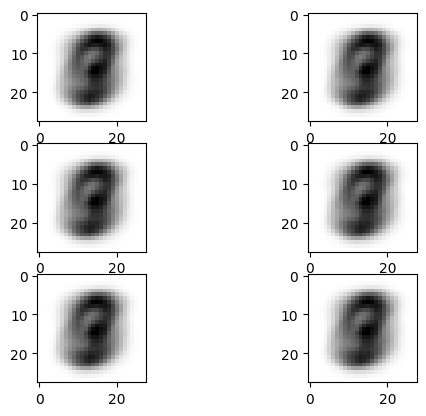

In [10]:
n_img=5
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.imshow(images[i],cmap="binary")

In [11]:
codings_grid=tf.reshape(codings,[1,3,4,codings_size])
larger_grid=tf.image.resize(codings_grid,size=[5,7])
interpolated_codings=tf.reshape(larger_grid,[-1,codings_size])
images=variational_decoder(interpolated_codings).numpy()

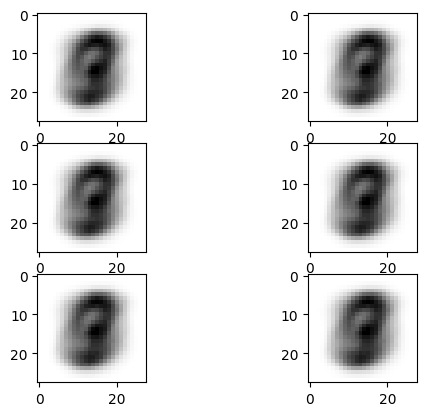

In [12]:
n_img=5
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.imshow(images[i],cmap="binary")